In [1]:
# ================= CELL 0: Imports & Config =================
import os
import json
import random
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from torchvision.models import resnet50, ResNet50_Weights

# ================= 1. Path & Configuration =================
IMAGE_DIR = '/root/data/VQA_RAD/images/'
JSON_PATH = '/root/data/VQA_RAD/VQA_RAD Dataset Public.json'
MODEL_SAVE_PATH = '/root/best_model.pth'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("DEVICE =", DEVICE)


DEVICE = cuda


In [2]:
# ================= CELL 1: Vocab (Question + Answer) =================
class QuestionVocab:
    """
    Word-level vocab for questions.
    """
    def __init__(self):
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.idx = 2

    def add_text(self, text):
        text = str(text).lower().replace('?', '').strip()
        for w in text.split():
            if w not in self.word2idx:
                self.word2idx[w] = self.idx
                self.idx2word[self.idx] = w
                self.idx += 1

    def encode(self, text):
        text = str(text).lower().replace('?', '').strip()
        return [self.word2idx.get(w, 1) for w in text.split()]

    def decode(self, ids):
        words = []
        for i in ids:
            i = int(i)
            w = self.idx2word.get(i, '<UNK>')
            if w != '<PAD>':
                words.append(w)
        return " ".join(words)

    def get_size(self):
        return self.idx


class AnswerVocab:
    """
    Label-level vocab for answers (IMPORTANT FIX).
    Each unique answer string is one class.
    """
    def __init__(self):
        self.ans2idx = {}
        self.idx2ans = {}
        self.idx = 0

    def add_answer(self, ans: str):
        ans = str(ans).lower().strip()
        if ans not in self.ans2idx:
            self.ans2idx[ans] = self.idx
            self.idx2ans[self.idx] = ans
            self.idx += 1

    def encode(self, ans: str):
        ans = str(ans).lower().strip()
        # 注意：训练/测试来自同一份 raw_data 拆分，所以通常不会 OOV
        # 但稳妥起见：如果出现 OOV，就映射到一个固定 id（这里选择 0）
        return self.ans2idx.get(ans, 0)

    def decode(self, idx: int):
        return self.idx2ans.get(int(idx), "<UNK>")

    def get_size(self):
        return self.idx


# Load Raw Data
with open(JSON_PATH, 'r') as f:
    raw_data = json.load(f)

# Build Vocabs
q_vocab = QuestionVocab()
a_vocab = AnswerVocab()

for entry in raw_data:
    q_vocab.add_text(entry['question'])
    a_vocab.add_answer(entry['answer'])

print("Question vocab size:", q_vocab.get_size())
print("Answer vocab size:", a_vocab.get_size())


Question vocab size: 1237
Answer vocab size: 517


In [3]:
# ================= CELL 2: Dataset / Loader =================
train_data, test_data = train_test_split(raw_data, test_size=0.2, random_state=42)

def type_distribution(data_list, title=""):
    c = Counter([str(d.get("answer_type","")).strip().upper() for d in data_list])
    total = sum(c.values())
    print(title)
    for k, v in c.items():
        if total > 0:
            print(f"  {k}: {v} ({v/total:.1%})")
    print()


type_distribution(train_data, "Train answer_type distribution:")
type_distribution(test_data, "Test answer_type distribution:")

class VQARADDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        entry = self.data[idx]

        # image
        img_path = os.path.join(IMAGE_DIR, entry['image_name'])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # question -> ids
        q_ids = q_vocab.encode(entry['question'])

        # answer -> class id (IMPORTANT FIX)
        a_id = a_vocab.encode(entry['answer'])

        # answer_type
        a_type = str(entry.get('answer_type', '')).upper()

        return image, torch.tensor(q_ids, dtype=torch.long), torch.tensor(a_id, dtype=torch.long), a_type


def collate_fn(batch):
    imgs, qs, ans, types = zip(*batch)
    qs_pad = torch.nn.utils.rnn.pad_sequence(qs, batch_first=True, padding_value=0)
    return torch.stack(imgs), qs_pad, torch.tensor(ans, dtype=torch.long), types


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

train_loader = DataLoader(
    VQARADDataset(train_data, transform),
    batch_size=32, shuffle=True, collate_fn=collate_fn
)
test_loader = DataLoader(
    VQARADDataset(test_data, transform),
    batch_size=32, shuffle=False, collate_fn=collate_fn
)


Train answer_type distribution:
  CLOSED: 1043 (58.0%)
  OPEN: 755 (42.0%)

Test answer_type distribution:
  OPEN: 194 (43.1%)
  CLOSED: 256 (56.9%)



In [4]:
# ================= CELL 3: Baseline Model (ResNet50 + LSTM) =================
class MedicalVQAModel(nn.Module):
    def __init__(self, q_vocab_size, a_vocab_size, q_emb_dim=128, q_lstm_dim=256, img_dim=256):
        super().__init__()

        weights = ResNet50_Weights.DEFAULT
        resnet = resnet50(weights=weights)

        self.cnn = nn.Sequential(*list(resnet.children())[:-1])  # (B,2048,1,1)
        self.cnn_fc = nn.Linear(2048, img_dim)

        self.embed = nn.Embedding(q_vocab_size, q_emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(q_emb_dim, q_lstm_dim, batch_first=True)

        self.classifier = nn.Sequential(
            nn.Linear(img_dim + q_lstm_dim, 512),
            nn.ReLU(),
            nn.Linear(512, a_vocab_size)
        )

    def forward(self, img, q):
        # image features
        img_f = self.cnn(img).view(img.size(0), -1)         # (B,2048)
        img_f = torch.relu(self.cnn_fc(img_f))              # (B,img_dim)

        # question features
        emb = self.embed(q)                                 # (B,T,emb)
        _, (h, _) = self.lstm(emb)
        q_f = h[-1]                                         # (B,q_lstm_dim)

        # fusion
        fused = torch.cat([img_f, q_f], dim=1)
        return self.classifier(fused)


model = MedicalVQAModel(q_vocab.get_size(), a_vocab.get_size()).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

print(model.__class__.__name__, "ready.")


MedicalVQAModel ready.


In [5]:
# ================= CELL 4: Evaluation (Top-1 + Top-5, by OPEN/CLOSED/ALL) =================
@torch.no_grad()
def evaluate_metrics(model, loader, topk=(1, 5)):
    model.eval()

    # stats[group][k] = {'c': correct, 't': total}
    groups = ["OPEN", "CLOSED", "ALL"]
    stats = {g: {k: {'c': 0, 't': 0} for k in topk} for g in groups}

    for imgs, qs, ans, types in loader:
        imgs, qs, ans = imgs.to(DEVICE), qs.to(DEVICE), ans.to(DEVICE)

        logits = model(imgs, qs)  # (B, C)

        # top-k predictions
        maxk = max(topk)
        _, pred_top = torch.topk(logits, k=maxk, dim=1)  # (B, maxk)

        for i in range(len(types)):
            t = str(types[i]).upper()
            if t not in ["OPEN", "CLOSED"]:
                t = "ALL"

            for k in topk:
                # correct if true label in top-k
                correct_k = (pred_top[i, :k] == ans[i]).any().item()

                # update for that type
                stats[t][k]['c'] += int(correct_k)
                stats[t][k]['t'] += 1

                # update for ALL too
                stats["ALL"][k]['c'] += int(correct_k)
                stats["ALL"][k]['t'] += 1

    # format output
    out = {}
    for g in groups:
        out[g] = {}
        for k in topk:
            c = stats[g][k]['c']
            t = stats[g][k]['t']
            out[g][f"top{k}"] = (c / t) if t > 0 else 0.0
    return out


In [6]:
# ================= CELL 5: Training Loop + Save Best =================
best_acc = 0.0
total_epochs = 40

history = {
    'train_loss': [],
    'test_top1_all': [],
    'test_top1_open': [],
    'test_top1_closed': [],
    'test_top5_all': [],
    'test_top5_open': [],
    'test_top5_closed': [],
}

print(f"Training started for {total_epochs} epochs...")

epoch_pbar = tqdm(range(total_epochs), desc="Overall Progress")

for epoch in epoch_pbar:
    model.train()
    epoch_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}", leave=False)

    for imgs, qs, ans, _ in train_pbar:
        imgs, qs, ans = imgs.to(DEVICE), qs.to(DEVICE), ans.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs, qs)
        loss = criterion(logits, ans)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        train_pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = epoch_loss / max(1, len(train_loader))
    history['train_loss'].append(avg_loss)

    metrics = evaluate_metrics(model, test_loader, topk=(1, 5))

    top1_all = metrics["ALL"]["top1"]
    top1_open = metrics["OPEN"]["top1"]
    top1_closed = metrics["CLOSED"]["top1"]
    top5_all = metrics["ALL"]["top5"]
    top5_open = metrics["OPEN"]["top5"]
    top5_closed = metrics["CLOSED"]["top5"]

    history['test_top1_all'].append(top1_all)
    history['test_top1_open'].append(top1_open)
    history['test_top1_closed'].append(top1_closed)
    history['test_top5_all'].append(top5_all)
    history['test_top5_open'].append(top5_open)
    history['test_top5_closed'].append(top5_closed)

    tqdm.write(
        f"Epoch [{epoch+1}/{total_epochs}] "
        f"AvgLoss: {avg_loss:.4f} | "
        f"Top1 ALL: {top1_all:.2%} (Open {top1_open:.2%}, Closed {top1_closed:.2%}) | "
        f"Top5 ALL: {top5_all:.2%} (Open {top5_open:.2%}, Closed {top5_closed:.2%})"
    )

    # Save best by ALL Top-1
    if top1_all > best_acc:
        best_acc = top1_all
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        tqdm.write(f"🌟 New best model saved! (Top1 ALL: {best_acc:.2%})")

print("\n" + "="*40)
print(f"Training Complete! Best Top1 ALL: {best_acc:.2%}")
print("="*40)


Training started for 40 epochs...


Overall Progress:   2%|▎         | 1/40 [00:24<15:37, 24.03s/it]        

Epoch [1/40] AvgLoss: 5.0349 | Top1 ALL: 27.27% (Open 0.00%, Closed 48.24%) | Top5 ALL: 53.66% (Open 4.12%, Closed 90.98%)
🌟 New best model saved! (Top1 ALL: 27.27%)



Overall Progress:   5%|▌         | 2/40 [00:47<14:59, 23.66s/it]        

Epoch [2/40] AvgLoss: 3.8078 | Top1 ALL: 30.38% (Open 0.00%, Closed 52.94%) | Top5 ALL: 56.32% (Open 10.82%, Closed 90.59%)
🌟 New best model saved! (Top1 ALL: 30.38%)


...

Epoch [38/40] AvgLoss: 0.6446 | Top1 ALL: 45.01% (Open 16.49%, Closed 66.27%) | Top5 ALL: 74.06% (Open 46.91%, Closed 94.51%)



Overall Progress:  98%|█████████▊| 39/40 [14:34<00:22, 22.28s/it]        

Epoch [39/40] AvgLoss: 0.6383 | Top1 ALL: 45.23% (Open 17.53%, Closed 65.88%) | Top5 ALL: 73.84% (Open 46.39%, Closed 94.51%)



Overall Progress: 100%|██████████| 40/40 [14:57<00:00, 22.43s/it]        

Epoch [40/40] AvgLoss: 0.6214 | Top1 ALL: 46.34% (Open 18.04%, Closed 67.45%) | Top5 ALL: 74.28% (Open 47.42%, Closed 94.51%)
🌟 New best model saved! (Top1 ALL: 46.34%)

Training Complete! Best Top1 ALL: 46.34%



FINAL EVALUATION ON TEST DATA (Best Checkpoint)
ALL    Top-1: 46.34% | Top-5: 74.28%
OPEN   Top-1: 18.04% | Top-5: 47.42%
CLOSED Top-1: 67.45% | Top-5: 94.51%


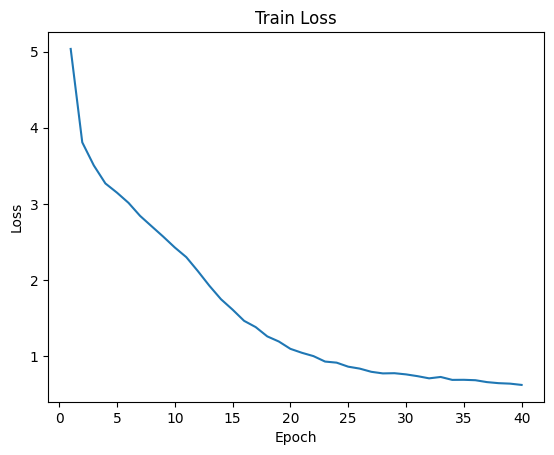

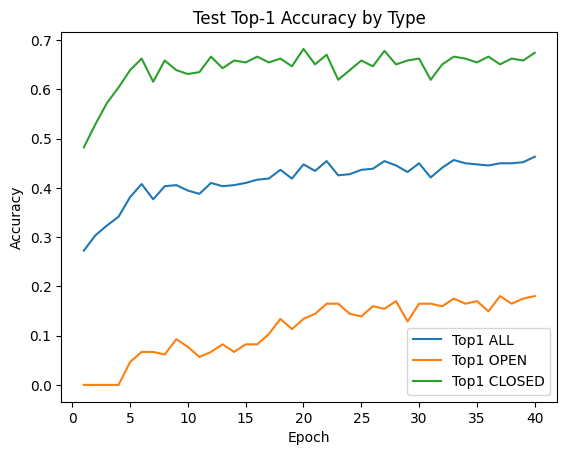

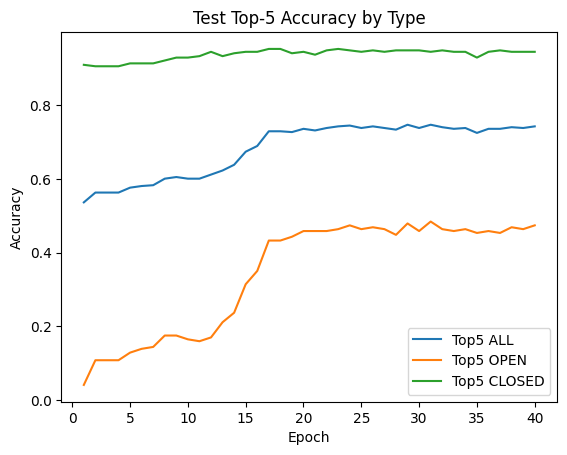

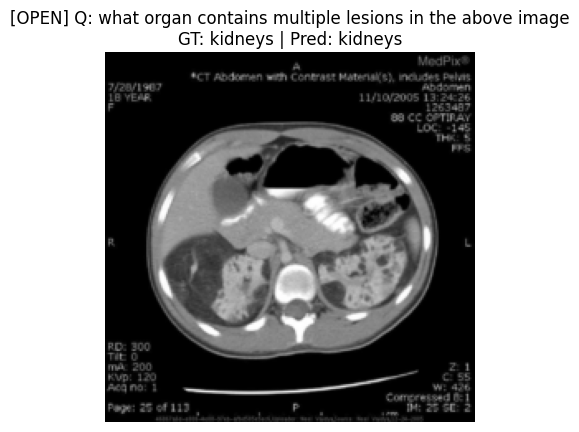

Top-k predictions:
  kidneys : 0.666
  fat : 0.275
  ct : 0.008
  one : 0.006
  small bowel : 0.004
------------------------------------------------------------


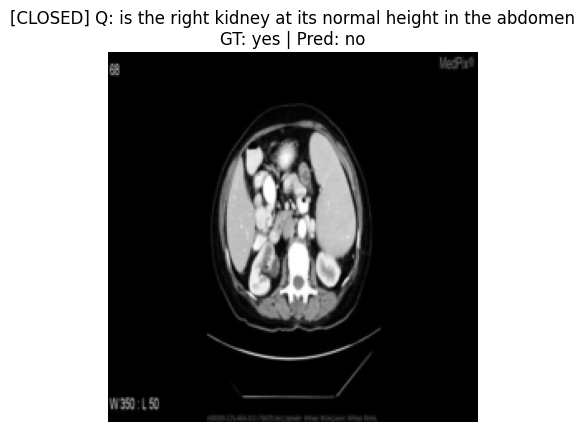

Top-k predictions:
  no : 0.541
  yes : 0.425
  enhancement of vessels : 0.006
  pneumothorax : 0.005
  enlarged, fluid-filled : 0.004
------------------------------------------------------------


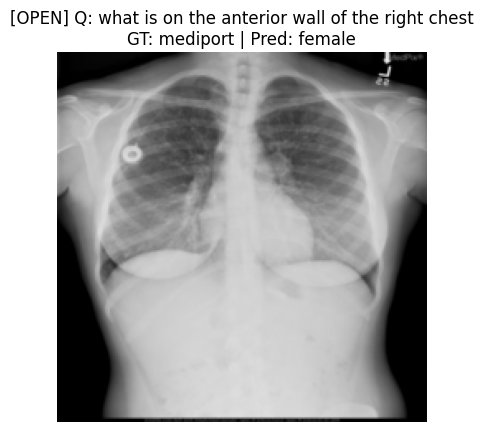

Top-k predictions:
  female : 0.431
  thickening of bronchi : 0.329
  bronchiectasis : 0.206
  stomach : 0.004
  the extremities : 0.004
------------------------------------------------------------


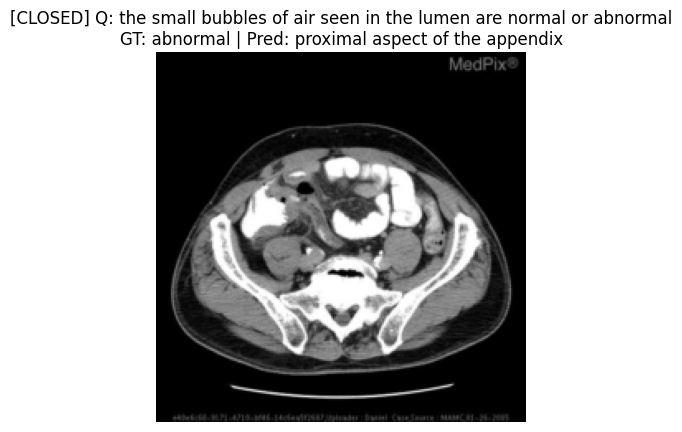

Top-k predictions:
  proximal aspect of the appendix : 0.864
  abnormal : 0.102
  enlarged, fluid-filled : 0.007
  ascending colon : 0.003
  haustra : 0.003
------------------------------------------------------------


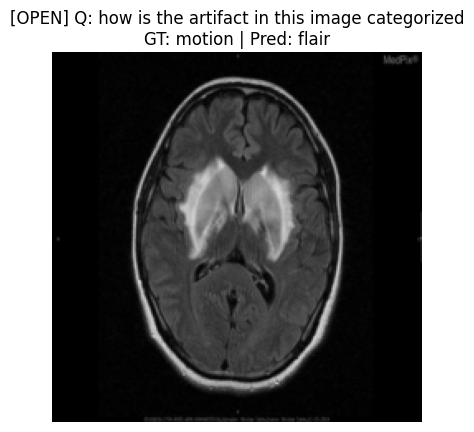

Top-k predictions:
  flair : 0.736
  basal ganglia : 0.133
  motion : 0.089
  t2 weighted : 0.011
  in the cortex and basal ganglia bilaterally : 0.004
------------------------------------------------------------


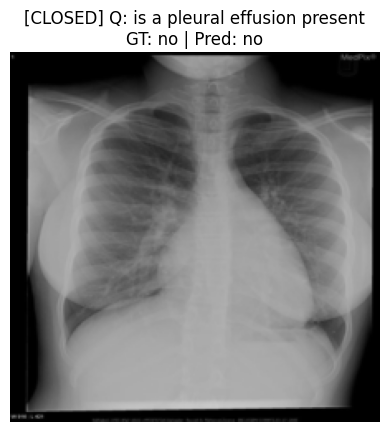

Top-k predictions:
  no : 0.509
  yes : 0.477
  left : 0.004
  right : 0.004
  solid : 0.001
------------------------------------------------------------


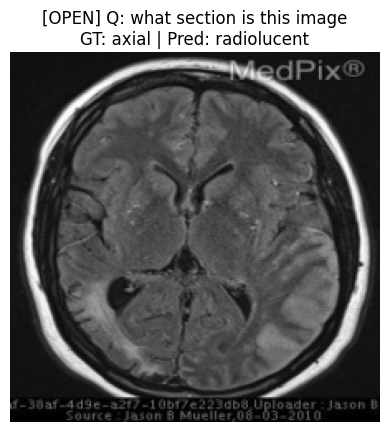

Top-k predictions:
  radiolucent : 0.852
  brain : 0.046
  axial : 0.028
  mri : 0.011
  toxoplasma, lymphoma, abscesses, other brain tumors : 0.009
------------------------------------------------------------


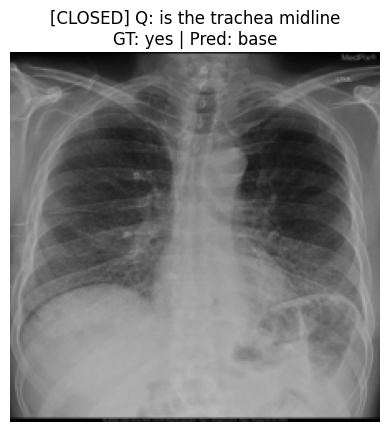

Top-k predictions:
  base : 0.634
  pa : 0.220
  right subclavian vein : 0.051
  yes : 0.044
  maybe : 0.015
------------------------------------------------------------


In [ ]:
# ================= CELL 6: Final Evaluation + Visualizations =================
# ---- Load best ----
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
model.to(DEVICE)

final_metrics = evaluate_metrics(model, test_loader, topk=(1, 5))

print("\n" + "="*40)
print("FINAL EVALUATION ON TEST DATA (Best Checkpoint)")
print(f"ALL    Top-1: {final_metrics['ALL']['top1']:.2%} | Top-5: {final_metrics['ALL']['top5']:.2%}")
print(f"OPEN   Top-1: {final_metrics['OPEN']['top1']:.2%} | Top-5: {final_metrics['OPEN']['top5']:.2%}")
print(f"CLOSED Top-1: {final_metrics['CLOSED']['top1']:.2%} | Top-5: {final_metrics['CLOSED']['top5']:.2%}")
print("="*40)

# ---- Plot history ----
def plot_history(history):
    epochs = list(range(1, len(history['train_loss']) + 1))

    plt.figure()
    plt.plot(epochs, history['train_loss'])
    plt.title("Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    plt.figure()
    plt.plot(epochs, history['test_top1_all'], label="Top1 ALL")
    plt.plot(epochs, history['test_top1_open'], label="Top1 OPEN")
    plt.plot(epochs, history['test_top1_closed'], label="Top1 CLOSED")
    plt.title("Test Top-1 Accuracy by Type")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history['test_top5_all'], label="Top5 ALL")
    plt.plot(epochs, history['test_top5_open'], label="Top5 OPEN")
    plt.plot(epochs, history['test_top5_closed'], label="Top5 CLOSED")
    plt.title("Test Top-5 Accuracy by Type")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history)


# ---- Show random predictions (image + Q + GT + Pred + Top-k) ----
def denormalize_img(img_tensor):
    # inverse of ImageNet normalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = (img_tensor.cpu() * std + mean).clamp(0, 1)
    return img

@torch.no_grad()
def show_predictions(model, dataset, n=8, topk=5, seed=42):
    random.seed(seed)
    model.eval()

    idxs = random.sample(range(len(dataset)), min(n, len(dataset)))
    for idx in idxs:
        img, q_ids, a_id, a_type = dataset[idx]

        img_b = img.unsqueeze(0).to(DEVICE)
        q_b = q_ids.unsqueeze(0).to(DEVICE)

        logits = model(img_b, q_b)[0]
        prob = torch.softmax(logits, dim=0)
        topv, topi = torch.topk(prob, k=topk)

        pred_id = int(topi[0].item())

        q_text = q_vocab.decode(q_ids.tolist())
        gt = a_vocab.decode(a_id.item())
        pred = a_vocab.decode(pred_id)

        plt.figure()
        img_vis = denormalize_img(img)
        plt.imshow(img_vis.permute(1, 2, 0))
        plt.axis("off")
        plt.title(f"[{a_type}] Q: {q_text}\nGT: {gt} | Pred: {pred}")
        plt.show()

        print("Top-k predictions:")
        for v, i in zip(topv.tolist(), topi.tolist()):
            print(f"  {a_vocab.decode(i)} : {v:.3f}")
        print("-" * 60)

test_dataset = VQARADDataset(test_data, transform)
show_predictions(model, test_dataset, n=8, topk=5, seed=42)


# ---- Yes/No confusion matrix (if yes/no exist) ----
from sklearn.metrics import precision_score, recall_score, f1_score

@torch.no_grad()
def eval_yesno_confusion_and_f1(model, loader):
    model.eval()
    yes_id = a_vocab.ans2idx.get("yes", None)
    no_id = a_vocab.ans2idx.get("no", None)

    if yes_id is None or no_id is None:
        print("No 'yes'/'no' labels found. Skip F1 evaluation.")
        return

    y_true, y_pred = [], []

    for imgs, qs, ans, _types in loader:
        imgs, qs, ans = imgs.to(DEVICE), qs.to(DEVICE), ans.to(DEVICE)
        logits = model(imgs, qs)
        preds = logits.argmax(dim=1)

        mask = (ans == yes_id) | (ans == no_id)
        if mask.any():
            y_true += ans[mask].cpu().tolist()
            y_pred += preds[mask].cpu().tolist()

    if len(y_true) == 0:
        print("No yes/no samples found.")
        return

    # 混淆矩阵
    cm = confusion_matrix(y_true, y_pred, labels=[no_id, yes_id])
    disp = ConfusionMatrixDisplay(cm, display_labels=["no", "yes"])
    disp.plot()
    plt.title("Yes/No Confusion Matrix (Closed Questions)")
    plt.show()

    # F1 / Precision / Recall（以 yes 为正类）
    precision = precision_score(y_true, y_pred, pos_label=yes_id)
    recall = recall_score(y_true, y_pred, pos_label=yes_id)
    f1 = f1_score(y_true, y_pred, pos_label=yes_id)

    print("Closed-ended (Yes/No) Evaluation:")
    print(f"  Precision (yes): {precision:.4f}")
    print(f"  Recall    (yes): {recall:.4f}")
    print(f"  F1-score  (yes): {f1:.4f}")
eval_yesno_confusion_and_f1(model, test_loader)